# **1. Data Loading**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving business_data.csv to business_data.csv


In [ ]:
import pandas as pd

df = pd.read_csv("business_data.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# **2. Data Cleaning & Defining Metrics**

In [ ]:
#convert date
df['Order_Date'] = pd.to_datetime(df['Date'])

In [ ]:
#creating sales metrics
df['Sales'] = df['Quantity'] * df['Price per Unit']

In [ ]:
#creating profit metrics
df['Profit'] = df['Sales'] * 0.30 #Profit has been estimated using an assumed 30% margin due to lack of cost data

# **3. Exploratory Data Analysis**

In [ ]:
#creating time-based metrics
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

monthly_revenue = df.groupby('Year_Month')['Sales'].sum()
monthly_profit = df.groupby('Year_Month')['Profit'].sum()

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Year_Month'>

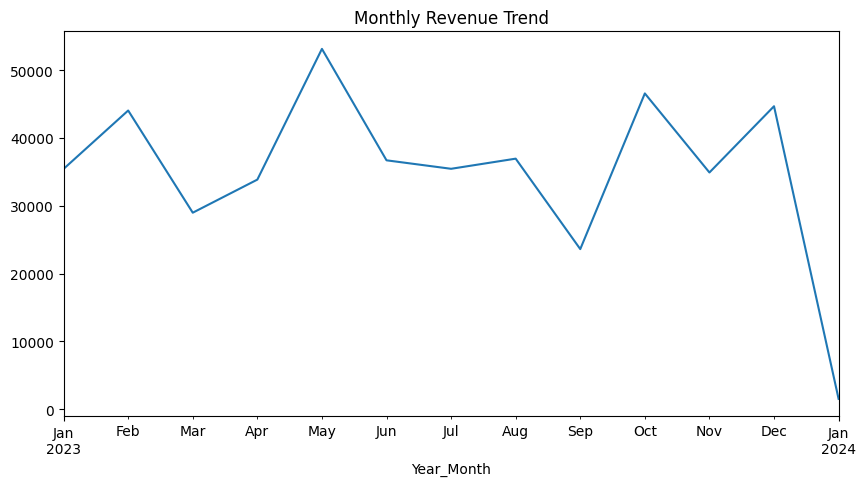

In [ ]:
monthly_revenue.plot(title = "Monthly Revenue Trend", figsize=(10,5))

In [ ]:
#Total revenue and profit

total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()

profit_margin = total_profit / total_revenue
total_revenue, total_profit, profit_margin

(np.int64(456000), np.float64(136800.0), np.float64(0.3))

Total Revenue = R456 000.00

Total Profit = R136 800.00

Profit margin = R30%

In [ ]:
#monthly revenue growth
monthly_revenue = df.groupby('Year_Month')['Sales'].sum()
monthly_growth = monthly_revenue.pct_change() * 100

monthly_growth.head()

,Sales
Year_Month,
2023-01,NaN
2023-02,24.287729
2023-03,-34.203359
2023-04,16.833391
2023-05,56.923531


<Axes: title={'center': 'Monthly Revenue Growth (%)'}, xlabel='Year_Month'>

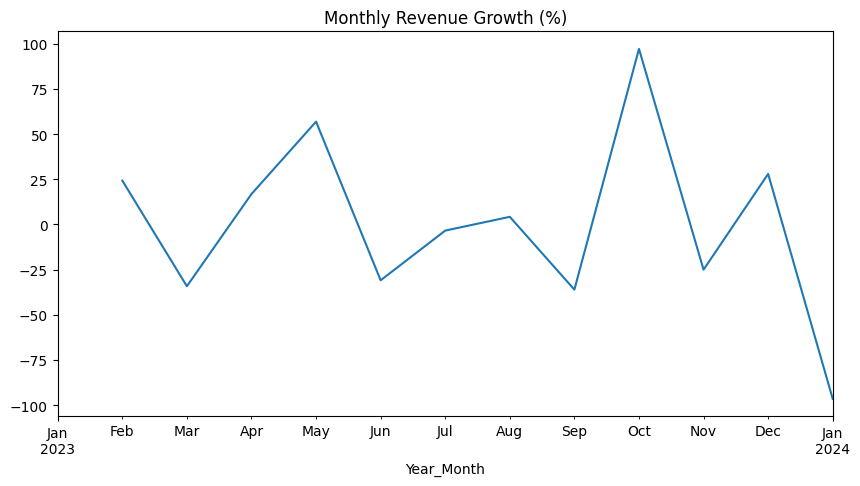

In [ ]:
monthly_growth.plot(title = "Monthly Revenue Growth (%)", figsize=(10,5))

<Axes: title={'center': 'Active Customers Over Time'}, xlabel='Year_Month'>

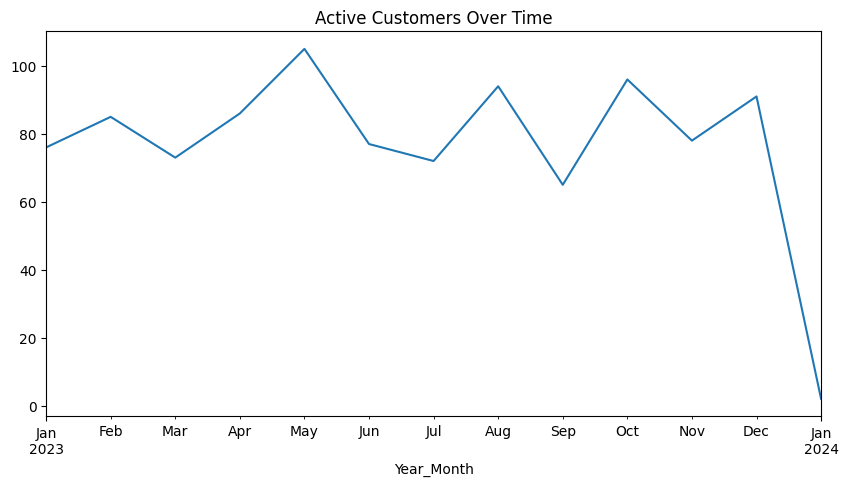

In [ ]:
#customer trend
monthly_customers = df.groupby('Year_Month')['Customer ID'].nunique()
monthly_customers.plot(title = "Active Customers Over Time", figsize=(10,5))

The customer base is shrinking over time

In [ ]:
#top performing categories
category_sales = df.groupby('Product Category')['Sales'].sum().sort_values(ascending=False)
category_sales

,Sales
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


In [ ]:
#low performing categories
low_profit_categories = df.groupby('Product Category')['Profit'].sum().sort_values()
low_profit_categories

,Profit
Product Category,
Beauty,43054.5
Clothing,46674.0
Electronics,47071.5


Some categories generate revenue but low profit.


# **4. Deeper Insights**

In [ ]:
#revenue vs profit by product category
category_performance = df.groupby('Product Category')[['Sales', 'Profit']].sum()
category_performance['Profit Margin'] = category_performance['Profit'] / category_performance['Sales']

category_performance.sort_values(by='Profit Margin')

,Sales,Profit,Profit Margin
Product Category,,,
Beauty,143515,43054.5,0.3
Clothing,155580,46674.0,0.3
Electronics,156905,47071.5,0.3


Electronics have the highest sales and generate the highest profit while Beauty products have the lowest sales and generate the least profit.

Profit margin is 30% for all product categories.

<Axes: title={'center': 'Monthly Profit Trend'}, xlabel='Year_Month'>

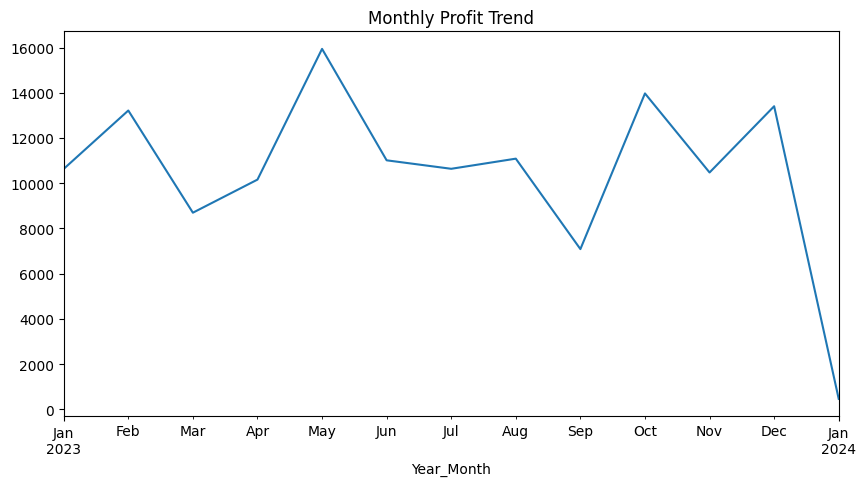

In [ ]:
#monthly profit trend
monthly_profit = df.groupby('Year_Month')['Profit'].sum()
monthly_profit.plot(title= "Monthly Profit Trend", figsize=(10,5))

Profit and Revenue has a positive correlation i.e., when revenue grows so does profit

<Axes: title={'center': 'Monthly Profit Growth %'}, xlabel='Year_Month'>

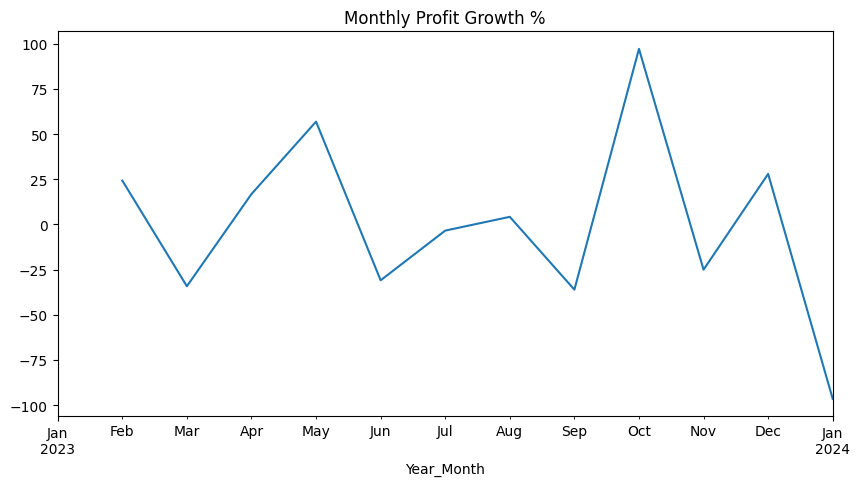

In [ ]:
monthly_profit_growth = monthly_profit.pct_change() * 100
monthly_profit_growth.plot(title = "Monthly Profit Growth %", figsize=(10,5))